In [1]:
import os
os.environ["CBEAM_BACKEND"] = "numpy"

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# =====================================================================
# CELL 2: IMPORT BATCH PIPELINE
# =====================================================================

from batch_propagation_pipeline import *
ideal_grid_positions = [
    (0.0000, 0.0000), (1.0000, 0.0000), (0.5000, 0.8660), (-0.5000, 0.8660),
    (-1.0000, 0.0000), (-0.5000, -0.8660), (0.5000, -0.8660), (2.0000, 0.0000),
    (1.5000, 0.8660), (1.0000, 1.7321), (0.0000, 1.7321), (-1.0000, 1.7321),
    (-1.5000, 0.8660), (-2.0000, 0.0000), (-1.5000, -0.8660), (-1.0000, -1.7321),
    (0.0000, -1.7321), (1.0000, -1.7321), (1.5000, -0.8660)
]
print("Batch pipeline imported successfully")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Batch pipeline imported successfully


In [3]:

import time
import numpy as np
 
from batch_propagation_pipeline import (
    get_waveguide_properties,
    IncidentFieldGenerator,
    ModalProjector,
    BatchPropagationPipeline,
    DEFAULT_GRID_RESOLUTION,
)
 
 
def profile_pipeline_preset(prop12, p, ifunc, grid_resolution=DEFAULT_GRID_RESOLUTION):
    """
    Manually replays BatchPropagationPipeline.__init__'s steps for one
    wavelength, timing each one. Does NOT construct a real pipeline --
    this is read-only profiling against an already-built prop12.
    """
    timings = {}
 
    t0 = time.perf_counter()
    wvg_props_input = get_waveguide_properties(prop12, mesh_z=0)
    t1 = time.perf_counter()
    timings["get_waveguide_properties(input, mesh_z=0)"] = t1 - t0
 
    wvg_props_output = get_waveguide_properties(prop12, mesh_z=p["z_ex"])
    t2 = time.perf_counter()
    timings["get_waveguide_properties(output, mesh_z=z_ex)"] = t2 - t1
 
    field_gen = IncidentFieldGenerator(p, ifunc, xp=np)
    t3 = time.perf_counter()
    timings["IncidentFieldGenerator.__init__ (mask + ifunc_matrix)"] = t3 - t2
 
    field_gen.precompute_interpolation_weights(wvg_props_input["points"])
    t4 = time.perf_counter()
    timings["precompute_interpolation_weights"] = t4 - t3
 
    modal_proj = ModalProjector(wvg_props_input, xp=np)
    t5 = time.perf_counter()
    timings["ModalProjector.__init__"] = t5 - t4
 
    # Replicates _precompute_delaunay_grid without needing a fully
    # constructed BatchPropagationPipeline instance.
    dummy = BatchPropagationPipeline.__new__(BatchPropagationPipeline)
    dummy.wvg_props_output = wvg_props_output
    _ = dummy._precompute_delaunay_grid(grid_resolution)
    t6 = time.perf_counter()
    timings[f"_precompute_delaunay_grid(resolution={grid_resolution})"] = t6 - t5
 
    print("\n" + "=" * 60)
    print("PRESET-PHASE TIMING BREAKDOWN")
    print("=" * 60)
    total = t6 - t0
    for label, dt in timings.items():
        bar = "#" * max(1, int(40 * dt / max(total, 1e-9)))
        print(f"{dt:7.3f} s  {bar:<40s}  {label}")
    print("-" * 60)
    print(f"{total:7.3f} s  TOTAL")
    print("=" * 60)
 
    return timings

In [4]:
# =====================================================================
# CELL 3: INITIALIZE SYSTEM PARAMETERS
# =====================================================================

p = get_simulation_parameters(3, 0.81)

print("\n" + "="*60)
print("SIMULATION PARAMETERS")
print("="*60)
print(f"Wavelength: {p['wl']} μm")
print(f"Lantern length: {p['z_ex']} μm")
print(f"Cladding radius: {p['rclad']} μm")
print(f"Jacket radius: {p['rjack']} μm")
print(f"Core radius: {p['rcore']:.3f} μm")
print(f"Taper factor: {p['taper_factor']}")
print(f"Available influence function: {p['ifunc_file']}")


SIMULATION PARAMETERS
Wavelength: 0.81 μm
Lantern length: 100000 μm
Cladding radius: 9.0 μm
Jacket radius: 27 μm
Core radius: 0.150 μm
Taper factor: 12.0
Available influence function: /raid2/gcarla/git/ANDES/andes/PASSATA_scripts/data/ifunc/ANDES_400pix_all_modes.fits


In [5]:
# =====================================================================
# CELL 4: LOAD INFLUENCE FUNCTION AND PROPAGATOR
# =====================================================================

import specula

print("Initializing SPECULA GPU...")
specula.init(0)
from specula.data_objects.ifunc import IFunc

print("Loading influence function...")
# UPDATE THIS LINE TO EXPLICITLY PASS THE DEVICE INDEX:
print(p["ifunc_file"])
ifunc = IFunc.restore(p["ifunc_file"]) 
mask = ifunc.mask_inf_func.get()



# Find the bounding box or centroid
y_cent = np.mean(np.where(mask > 0)[0])
x_cent = np.mean(np.where(mask > 0)[1])
# Desired center (assuming square mask)
center_y = mask.shape[0] // 2
center_x = mask.shape[1] // 2
shift_y = int(center_y - y_cent)
shift_x = int(center_x - x_cent)

print('shift_x, shift_y', shift_x, shift_y)

mask_centered = np.roll(mask, shift_y, axis=0)
mask_centered = np.roll(mask_centered, shift_x, axis=1)
ifunc.mask_inf_func.set(mask_centered)

# Replace the mask
ifunc.mask_inf_func.set(mask_centered)

print(f"  Influence function modes: {len(ifunc.influence_function)}")

print("\nBuilding photonic lantern propagator...")
prop12 = build_and_characterize_lantern(p)

print(f"  Propagator type: {type(prop12).__name__}")
print(f"  Total z range: {prop12.zs[0]:.0f} to {prop12.zs[-1]:.0f} μm")

2026-07-29 18:35:03,696 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.1.1
2026-07-29 18:35:03,844 [INFO]: [specula]: Default device is GPU number 0


Initializing SPECULA GPU...
Loading influence function...
/raid2/gcarla/git/ANDES/andes/PASSATA_scripts/data/ifunc/ANDES_400pix_all_modes.fits
shift_x, shift_y 0 0
  Influence function modes: 10

Building photonic lantern propagator...
mesh has  12495  points
computing modes ...
current z: 50000 / 50000 ; current zstep: 40.0                 
computing coupling matrix ...
current z: 50000.0 / 50000.0        time elapsed:  336.61920285224915
mesh has  12495  points
computing modes ...
current z: 100000 / 100000 ; current zstep: 5120.0              
computing coupling matrix ...
current z: 100000.0 / 100000.0        time elapsed:  53.073989152908325
  Propagator type: ChainPropagator
  Total z range: 0 to 100000 μm


Creating batch propagation pipeline...

[Interpolation Setup]
  Padded grid size: 1600
  Grid parity: even
  Center offset: 800.0
  Pixel scale: 1 μm/pixel
  Mesh X range: [-26.852, 26.852] μm
  Mesh Y range: [-27.000, 27.000] μm
  Valid interpolation points: 12495 / 12495

=== RUNNING INPUT PSF CENTERING & SCALE DIAGNOSTIC (FIXED VERSION) ===

[MASK CENTERING CHECK]
  Mask shape: (400, 400)
  Mask centroid: (199.49, 199.81)
  Expected center: (199.50, 199.50)
  Offset: (-0.013, 0.308) pixels
  ⚠️  WARNING: Mask is off-center! This will cause PSF misalignment.
  Recommendation: Re-center the mask before loading or adjust in IFunc object.

[FFT GRID CHECK]
  FFT grid shape: (1600, 1600)
  FFT center index: (800, 800)
  PSF peak index: (np.int64(800), np.int64(800))
  Centering offset: (np.int64(0), np.int64(0)) pixels
  PSF centroid (subpixel): (799.999, 799.997)
  Centroid offset: (-0.001, -0.003) pixels

[MESH INTERPOLATION CHECK]
  Mesh PSF peak: (0.068, 0.067) μm
  Nearest core (#10

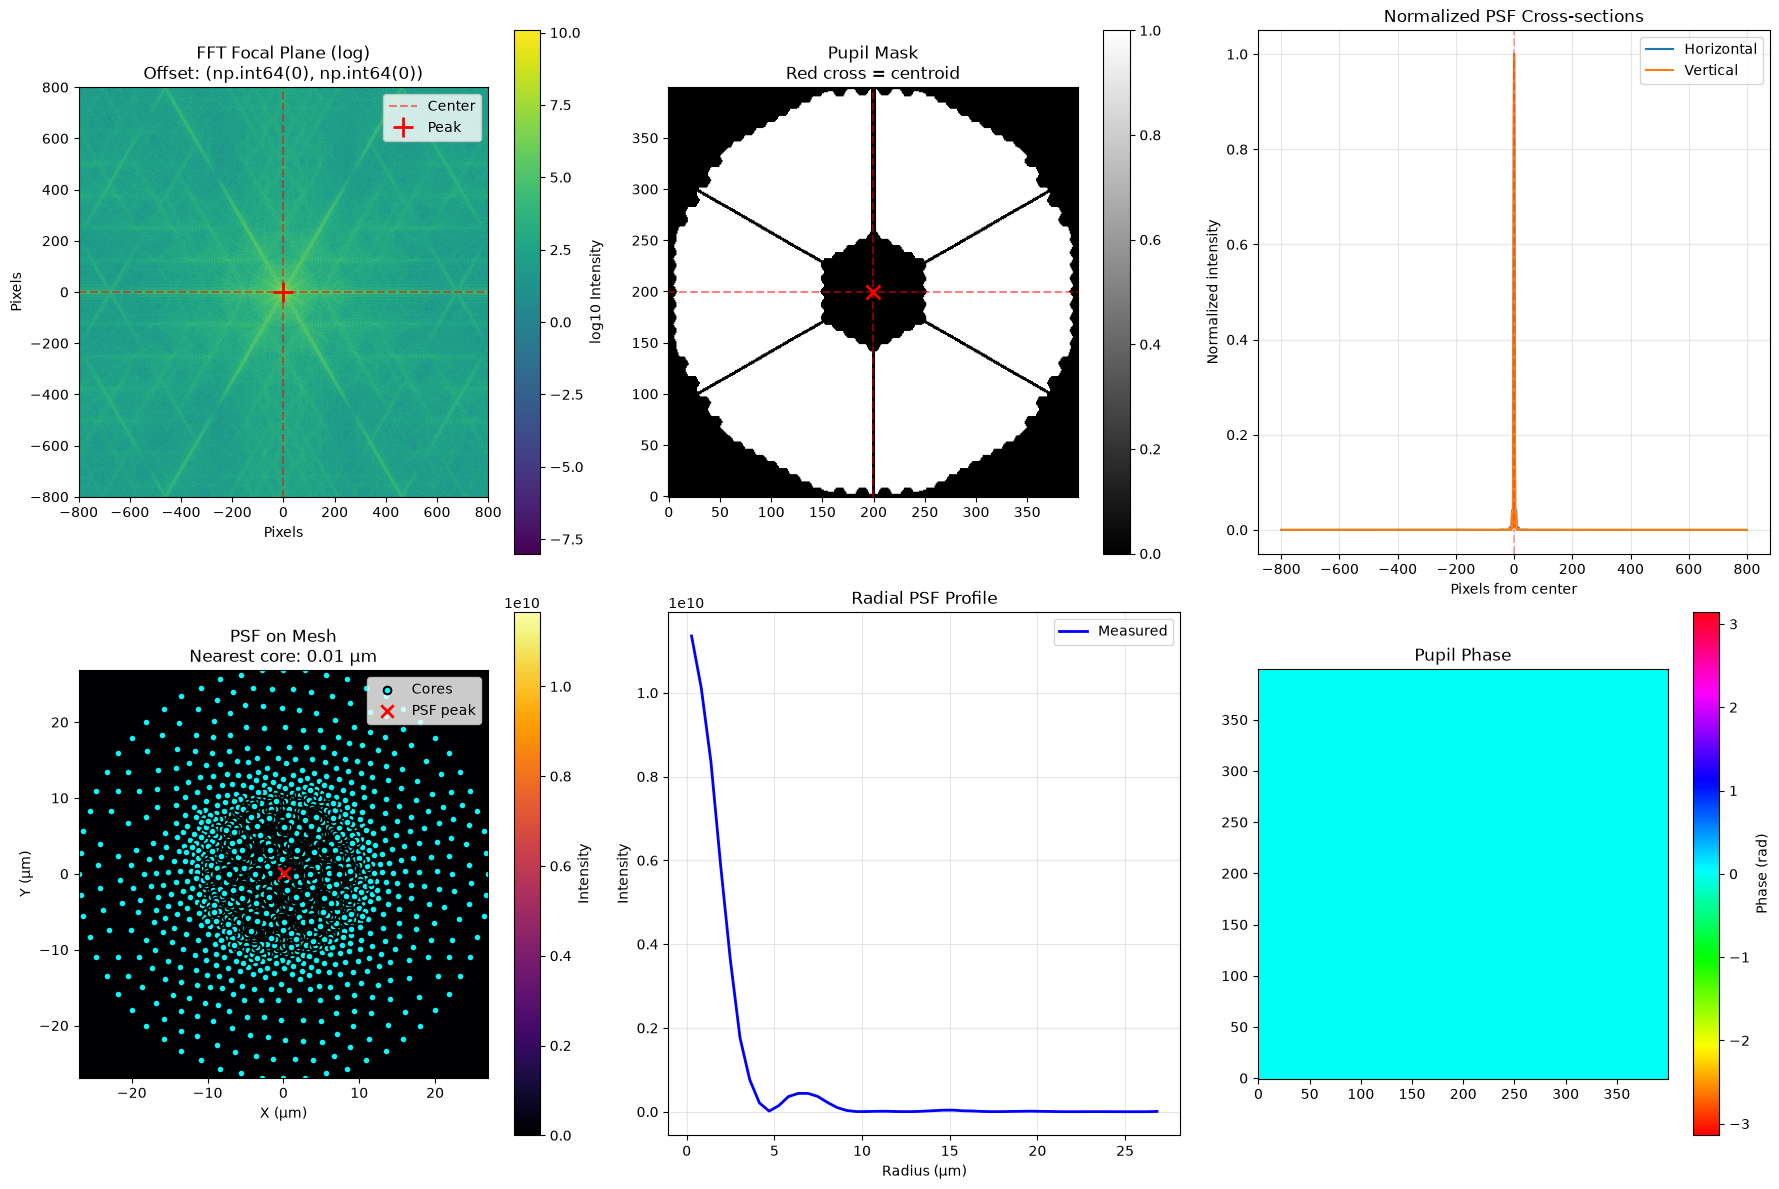


DIAGNOSTIC SUMMARY
Issues found:
  ⚠️  Mask is off-center

Recommendations:
  1. Check mask centering in IFunc
  2. Verify pixel_scale_um matches FFT grid spacing
  3. Check mesh interpolation coordinate mapping
Waveguide Properties:
  Input modes: 20
  Output modes: 20
  Mesh points at input: 12495
  Mesh points at output: 12495


In [6]:
# =====================================================================
# CELL 5: CREATE BATCH PROPAGATION PIPELINE
# =====================================================================

print("Creating batch propagation pipeline...\n")
pipeline = BatchPropagationPipeline(prop12, p, ifunc)

diagnose_input_psf(pipeline)

print("Waveguide Properties:")
print(f"  Input modes: {pipeline.wvg_props_input['n_modes']}")
print(f"  Output modes: {pipeline.wvg_props_output['n_modes']}")
print(f"  Mesh points at input: {pipeline.wvg_props_input['points'].shape[0]}")
print(f"  Mesh points at output: {pipeline.wvg_props_output['points'].shape[0]}")

In [7]:
profile_pipeline_preset(prop12, p, ifunc)

[Interpolation Setup]
  Padded grid size: 1600
  Grid parity: even
  Center offset: 800.0
  Pixel scale: 1 μm/pixel
  Mesh X range: [-26.852, 26.852] μm
  Mesh Y range: [-27.000, 27.000] μm
  Valid interpolation points: 12495 / 12495

PRESET-PHASE TIMING BREAKDOWN
  0.000 s  #                                         get_waveguide_properties(input, mesh_z=0)
  0.000 s  #                                         get_waveguide_properties(output, mesh_z=z_ex)
  0.002 s  #                                         IncidentFieldGenerator.__init__ (mask + ifunc_matrix)
  0.000 s  #                                         precompute_interpolation_weights
  0.000 s  #                                         ModalProjector.__init__
  3.252 s  #######################################   _precompute_delaunay_grid(resolution=400)
------------------------------------------------------------
  3.255 s  TOTAL


{'get_waveguide_properties(input, mesh_z=0)': 0.00022415071725845337,
 'get_waveguide_properties(output, mesh_z=z_ex)': 0.0004233717918395996,
 'IncidentFieldGenerator.__init__ (mask + ifunc_matrix)': 0.0020490512251853943,
 'precompute_interpolation_weights': 0.0004843771457672119,
 'ModalProjector.__init__': 0.00011548399925231934,
 '_precompute_delaunay_grid(resolution=400)': 3.2520895078778267}

In [8]:
#coeff1, _labels1 = create_random_aberration_configs(n=1, m=10, minv=-0, maxv=0)
coeff0, _labels0 = create_random_aberration_configs(n=100, m=9, minv=400, maxv=400)
coeff1, labels = create_ramp_aberration_configs([0],20,0,400)

In [9]:
print("\nGenerating batch of input modal coefficients...\n")
import time
print(coeff0.shape)
start_time = time.time()
u0_batch = pipeline.generate_batch_modal_coefficients(coeff0, use_gpu=False)
elapsed = time.time() - start_time
print(f"\generate_batch_modal_coefficients Complete:")
print(f"  Elapsed time: {elapsed:.1f} seconds")
print(f"Input Modal Coefficient Batch:")
print(f"  Shape: {u0_batch.shape}")
print(f"  Dtype: {u0_batch.dtype}")
print(f"  Memory: {u0_batch.nbytes / 1e6:.1f} MB")

u1_batch = pipeline.generate_batch_modal_coefficients(coeff1)



Generating batch of input modal coefficients...

(100, 9)
\generate_batch_modal_coefficients Complete:
  Elapsed time: 1.4 seconds
Input Modal Coefficient Batch:
  Shape: (100, 20)
  Dtype: complex128
  Memory: 0.0 MB


In [10]:
# =====================================================================
# CELL 8: PROPAGATE BATCH THROUGH LANTERN
# =====================================================================
import time
start_time = time.time()

print("\nPropagating batch through lantern...")
#uf_batch, zs, us_batch = pipeline.propagate_batch_single(u1_batch)
#uf_batch, zs, us_batch = pipeline.propagate_batch(u1_batch)

elapsed = time.time() - start_time

print(f"\nPropagation Complete:")
print(f"  Elapsed time: {elapsed:.1f} seconds")
start_time = time.time()


#uf_batch, zs, us_batch = pipeline.propagate_batch_single(u0_batch)
uf_batch0, zs0, us_batch0 = pipeline.propagate_batch(u0_batch)
uf_batch1, zs1, us_batch1 = pipeline.propagate_batch(u1_batch)

elapsed = time.time() - start_time

print(f"\nPropagation Complete:")
print(f"  Elapsed time: {elapsed:.1f} seconds")
print(f"  Output modal coefficients shape: {uf_batch0.shape}")
print(f"  Propagation z-points: {len(zs0)}")


Propagating batch through lantern...

Propagation Complete:
  Elapsed time: 0.0 seconds
  Propagating 100 fields (chunk_size=100) ...
    propagation chunk 0–99 done.
  Batch propagation complete.
  Propagating 20 fields (chunk_size=20) ...
    propagation chunk 0–19 done.
  Batch propagation complete.

Propagation Complete:
  Elapsed time: 73.6 seconds
  Output modal coefficients shape: (100, 20)
  Propagation z-points: 734


In [11]:
uf_batch0[0]

array([-0.37671078-0.21274538j,  0.4555662 -0.17007306j,
        0.28181608-0.12269891j, -0.07682569-0.25141091j,
        0.0978722 +0.3229286j ,  0.11009653-0.0951229j ,
       -0.16462932+0.05846165j,  0.2148169 -0.08287368j,
        0.07859984-0.23403243j,  0.1187093 +0.11892307j,
        0.09217512-0.04611049j,  0.16226644-0.02982315j,
       -0.11636919+0.02801082j, -0.09730737+0.00320009j,
        0.08795033+0.06231109j,  0.00856066-0.01258622j,
       -0.05886792+0.08898926j,  0.0703776 +0.05772708j,
        0.        -0.j        , -0.02732651+0.08507153j])

In [12]:
# =====================================================================
# CELL 9: RECONSTRUCT OUTPUT SPATIAL FIELDS
# =====================================================================

print("Reconstructing output spatial fields...\n")

E_output_batch0 = pipeline.reconstruct_batch_output_fields(uf_batch0)
E_output_batch1 = pipeline.reconstruct_batch_output_fields(uf_batch1)


print(f"Output Spatial Fields:")
print(f"  Shape: {E_output_batch0.shape}")
print(f"  Dtype: {E_output_batch0.dtype}")
print(f"  Memory: {E_output_batch0.nbytes / 1e6:.1f} MB")


Reconstructing output spatial fields...

Output Spatial Fields:
  Shape: (100, 12495)
  Dtype: complex128
  Memory: 20.0 MB


In [13]:
# =====================================================================
# CELL 10: INTERPOLATE TO REGULAR GRID
# =====================================================================

print("Interpolating output fields to regular grid...\n")

uf_2d_batch0, X_plot0, Y_plot0 = pipeline.interpolate_output_to_grid(E_output_batch0, grid_resolution=200)
uf_2d_batch1, X_plot1, Y_plot1 = pipeline.interpolate_output_to_grid(E_output_batch1, grid_resolution=200)

print(f"Interpolated Intensity Maps:")
print(f"  Shape: {uf_2d_batch0.shape}")
print(f"  X range: [{X_plot0.min():.2f}, {X_plot0.max():.2f}] μm")
print(f"  Y range: [{Y_plot0.min():.2f}, {Y_plot0.max():.2f}] μm")
print(f"  Memory: {uf_2d_batch0.nbytes / 1e6:.1f} MB")

Interpolating output fields to regular grid...

Interpolated Intensity Maps:
  Shape: (100, 200, 200)
  X range: [-27.00, 27.00] μm
  Y range: [-26.85, 26.85] μm
  Memory: 32.0 MB


Generating visualization...



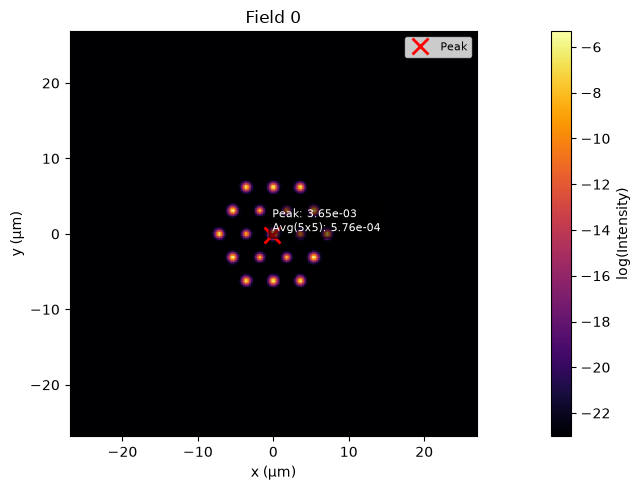

In [14]:
# =====================================================================
# CELL 11: VISUALIZE BATCH OUTPUT
# =====================================================================

print("Generating visualization...\n")

# Create titles for each field
titles = [] #[f"Mode {c['mode_idx']}, {c['amplitude_nm']:.0f} nm" 
          #for c in aberration_configs]

# Visualize
visualize_batch_output(uf_2d_batch1[0:2], X_plot1, Y_plot1, titles, maxv=1, show_arrow=False)

In [15]:
# --- Step 1: Detect core centers from the first output field ---
first_intensity = uf_2d_batch0.sum(axis=0)
# shape (grid_resolution, grid_resolution)
# But we need the spatial coordinates X_plot, Y_plot from the pipeline.
# Actually, we have X_plot, Y_plot from the interpolation.

# Reuse your calibration function, but now pass the 2D intensity map and the mesh points?
# The calibration function expects a (N_points,) profile and mesh.points.
# But we already have the interpolated grid. Let's create a function that works directly on grid.


# Detect centers from the first output field
core_centers = detect_centers_from_grid(first_intensity, X_plot0, Y_plot0)
print(f"Detected {len(core_centers)} core centers")

Detected 19 core centers


In [16]:

# Detect centers once
x_min, y_min = X_plot0[0,0], Y_plot0[0,0]
dx = X_plot0[0,1] - X_plot0[0,0]
dy = Y_plot0[1,0] - Y_plot0[0,0]

core_centers = detect_centers_from_grid(first_intensity, X_plot0, Y_plot0)
ideal_permutation = map_evaluated_to_ideal_geometry(core_centers, ideal_grid_positions)


[Geometric Fit] Estimated physical core pitch: 3.606 µm
[Geometric Fit] Residual matching RMS error: 1.2376e-02



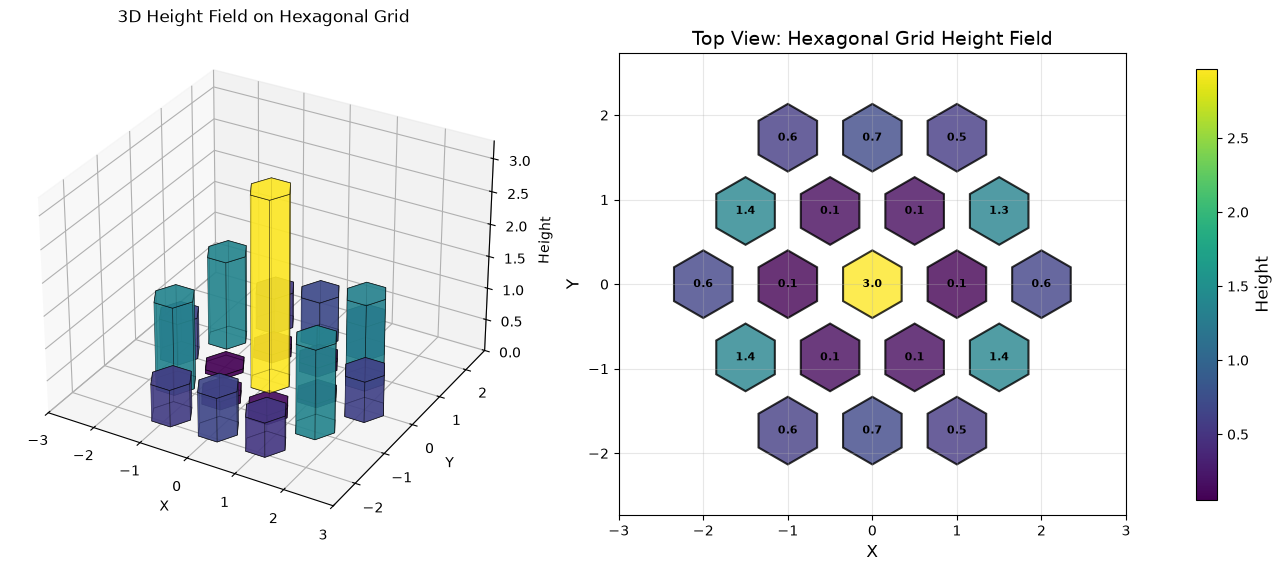

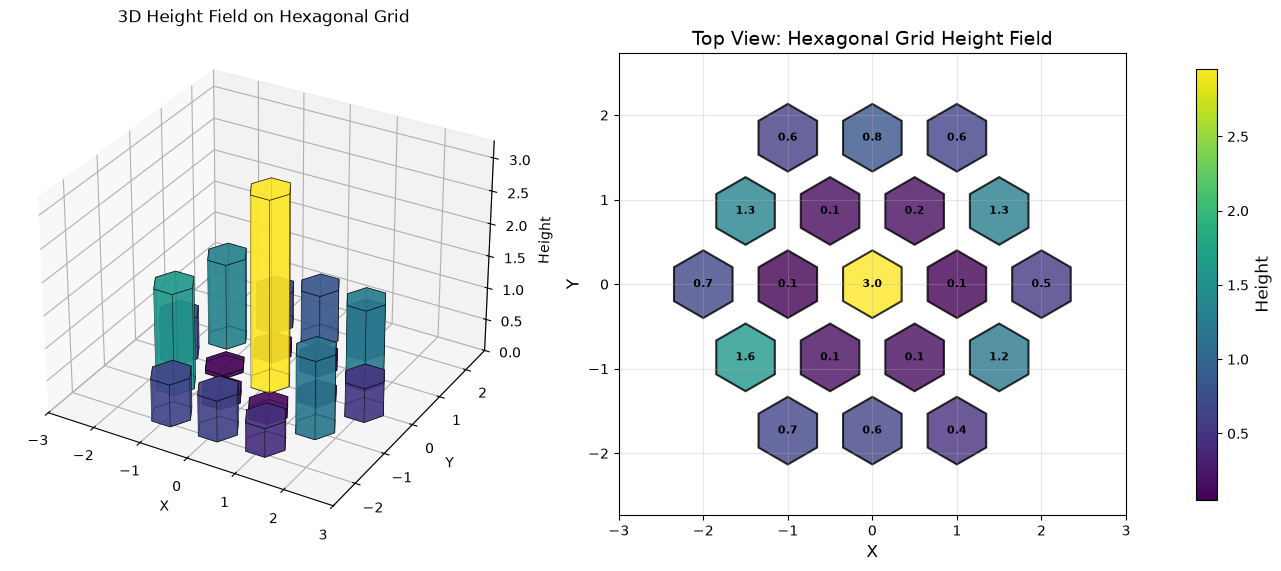

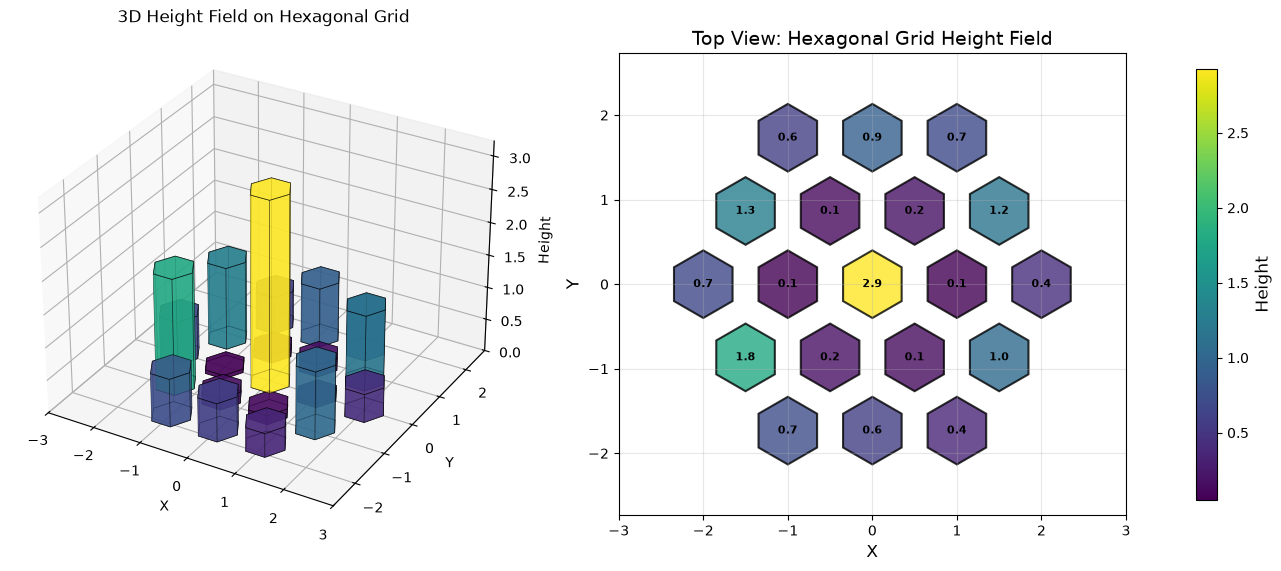

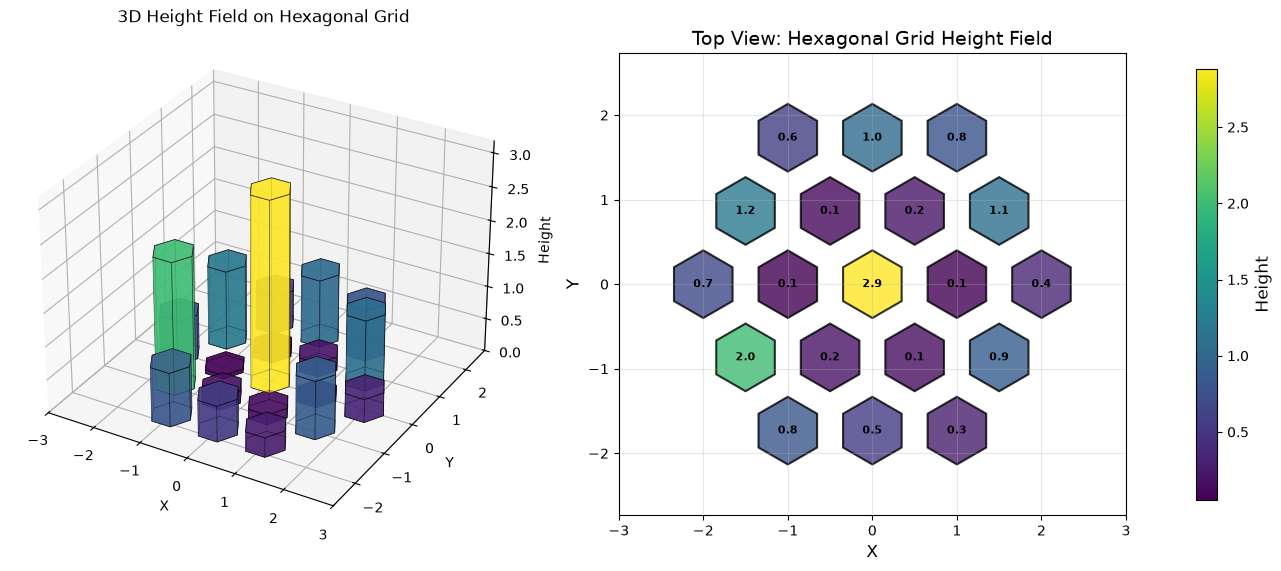

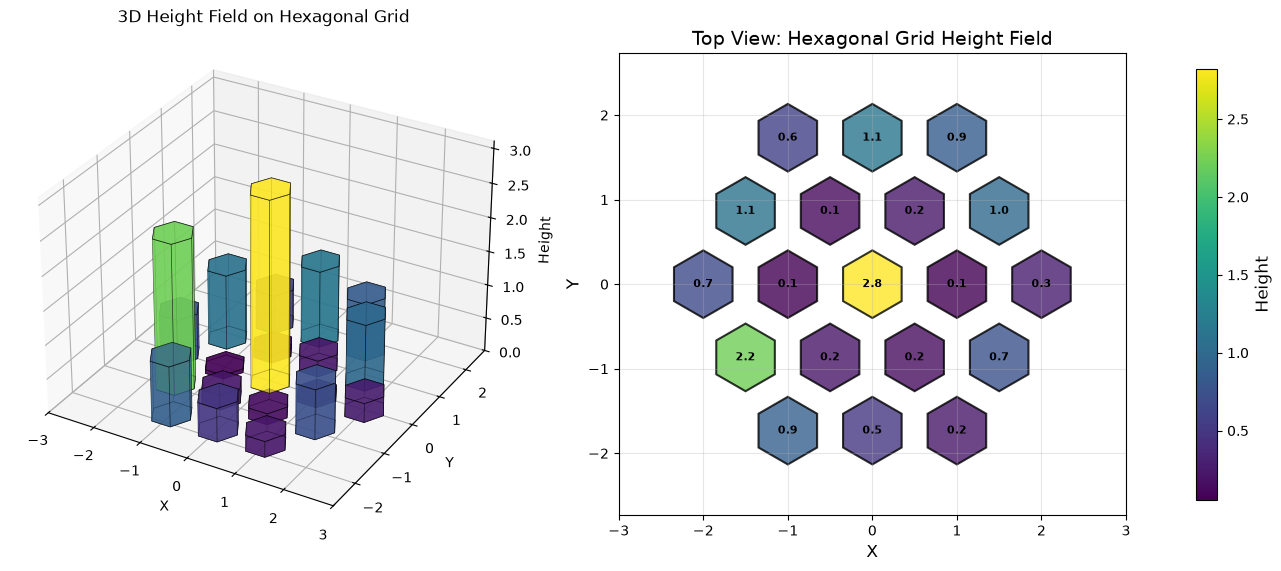

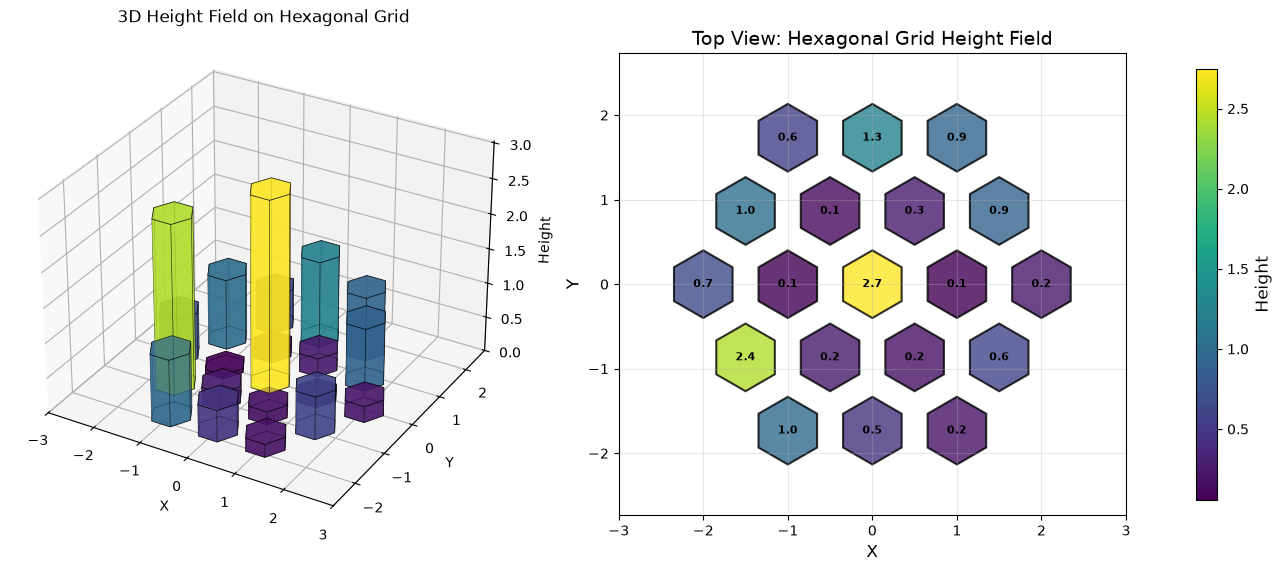

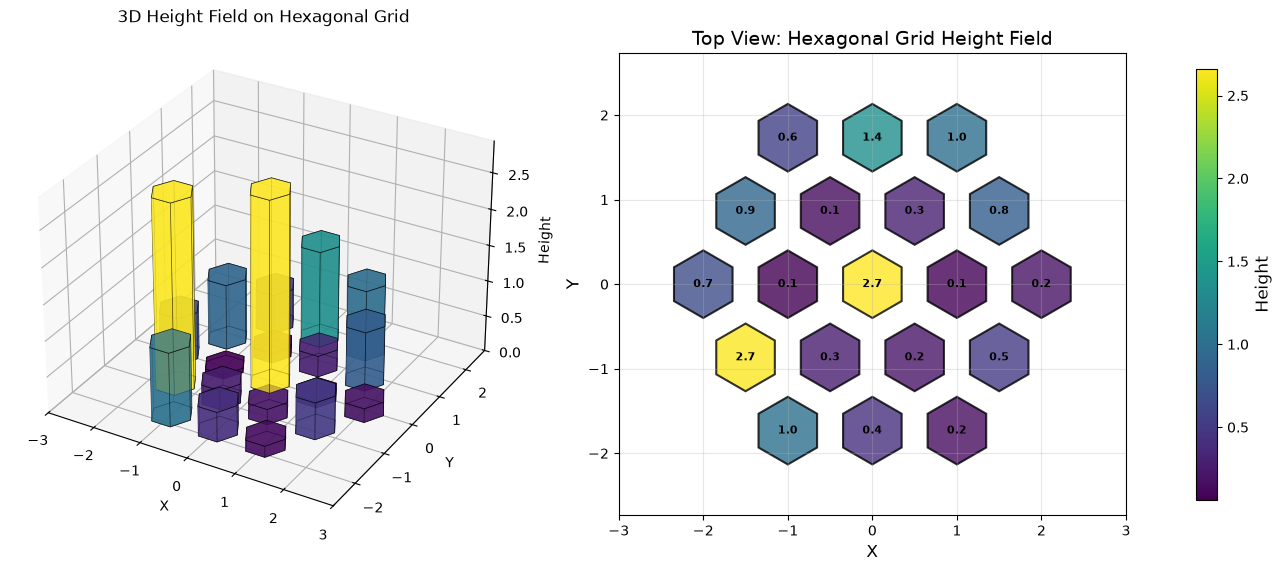

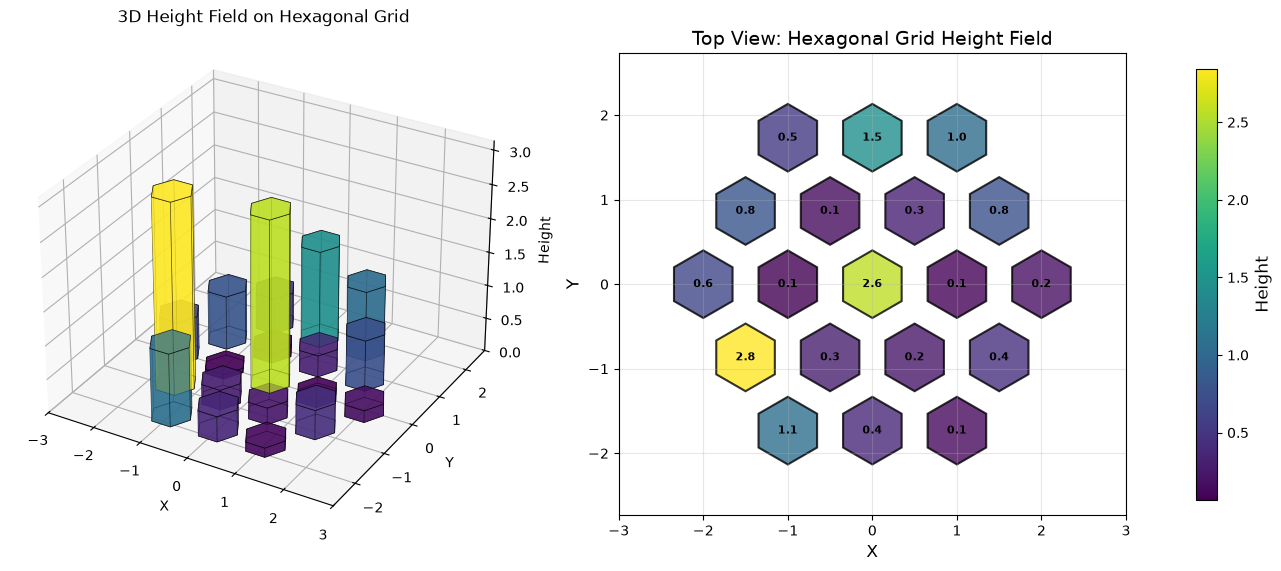

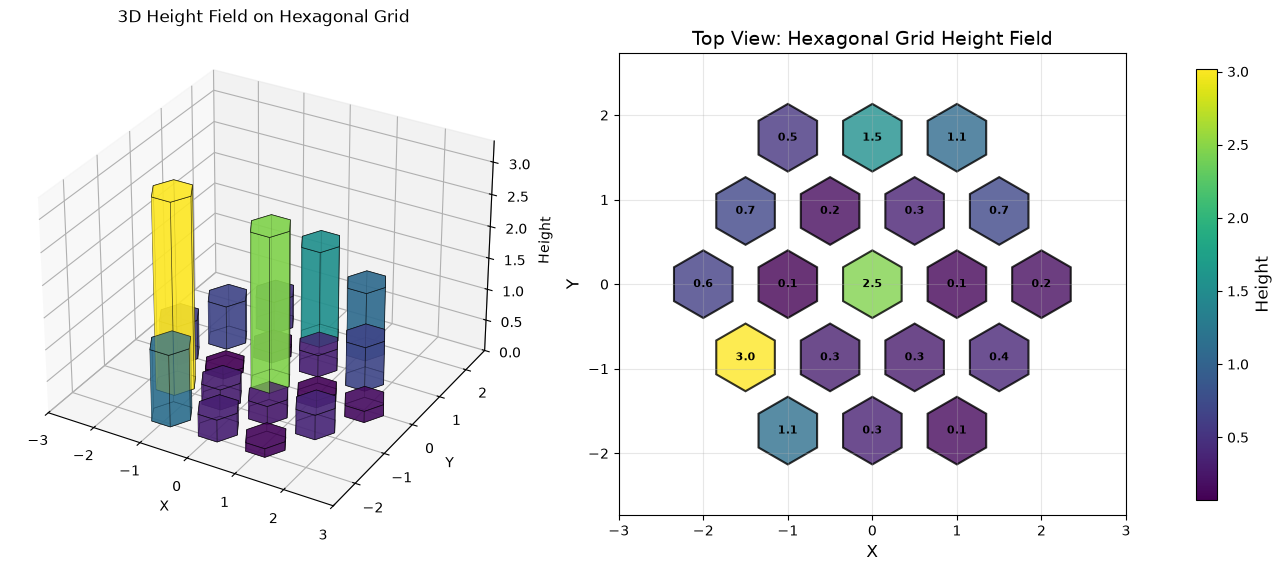

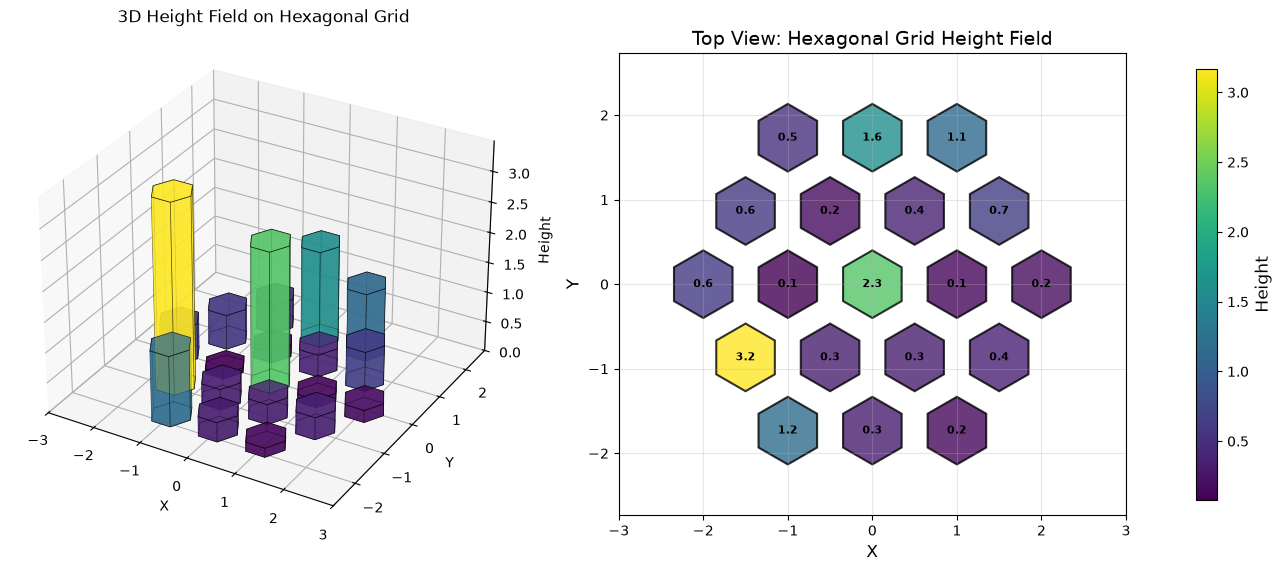

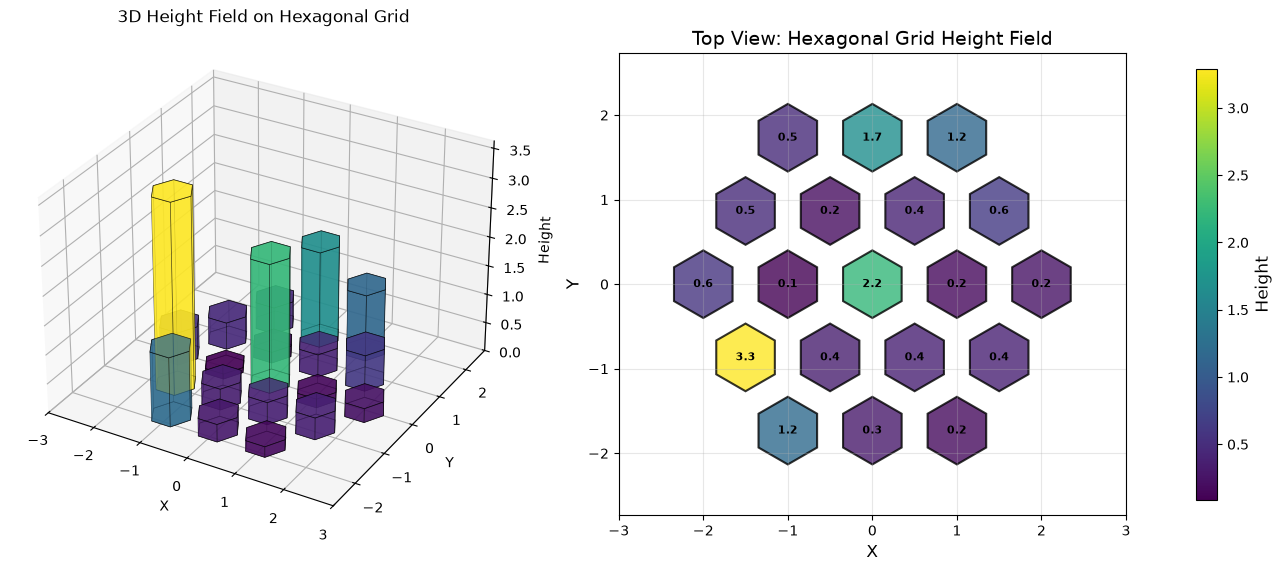

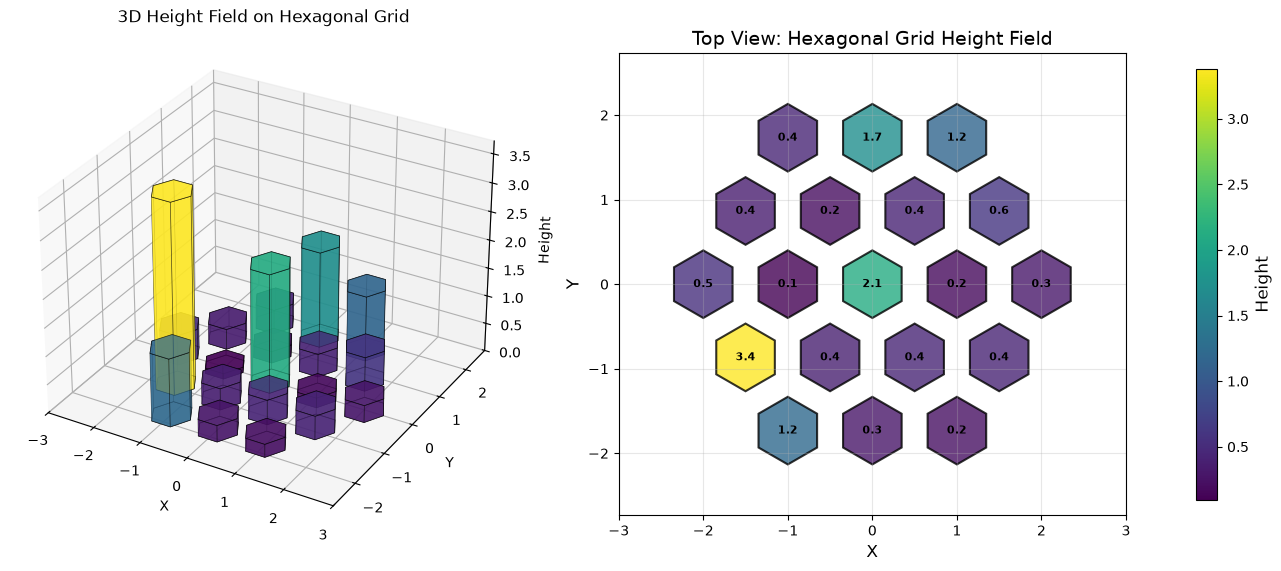

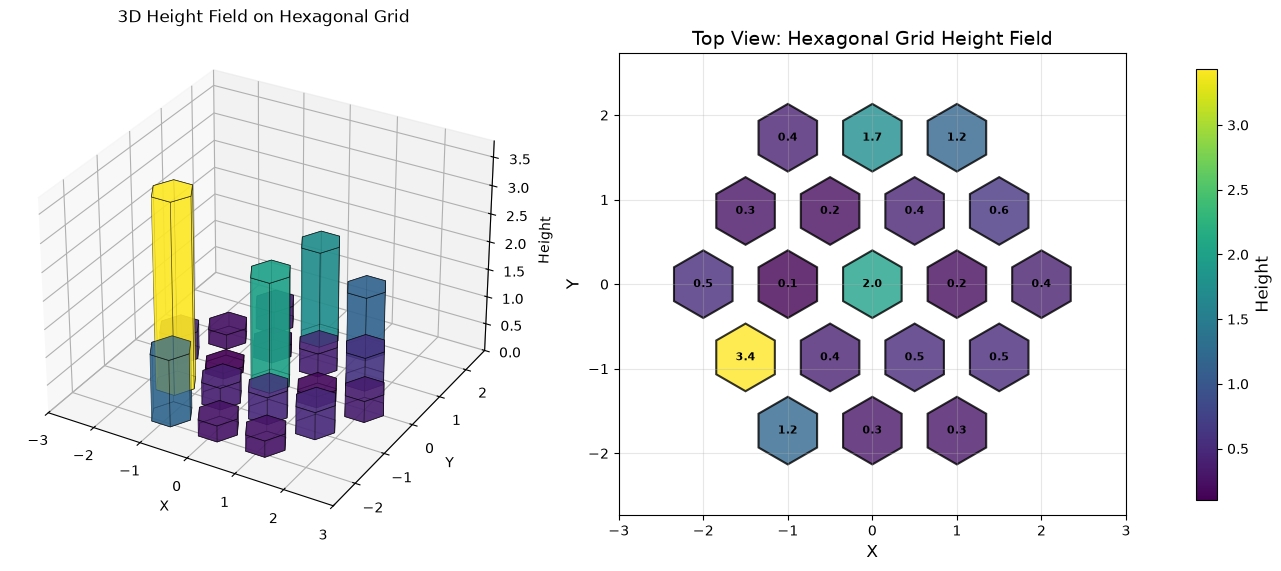

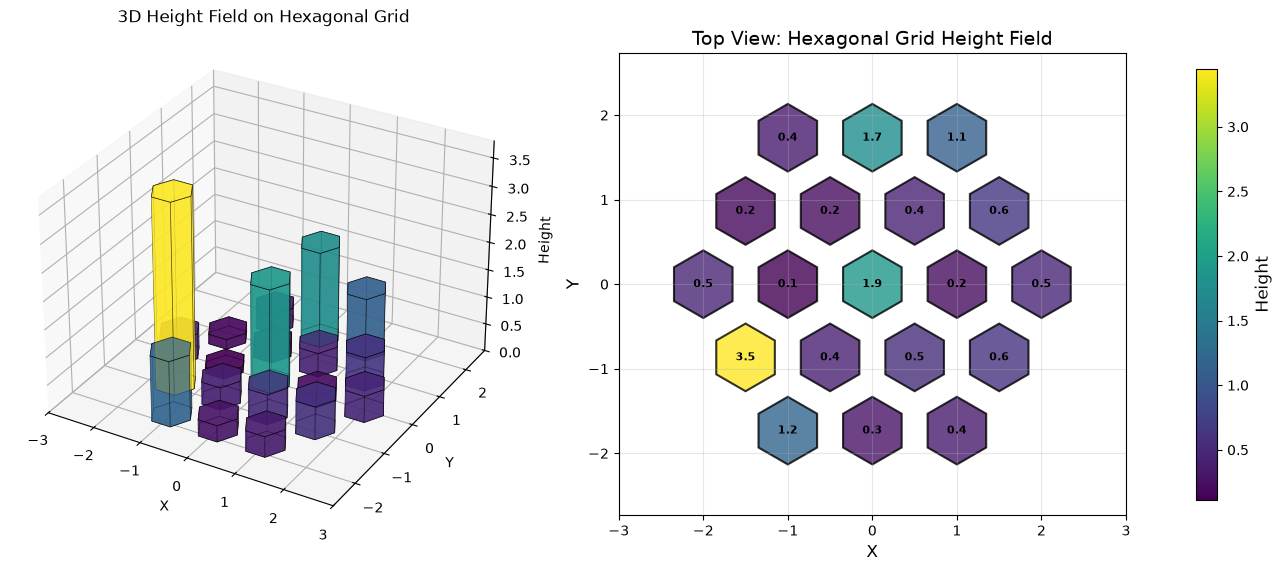

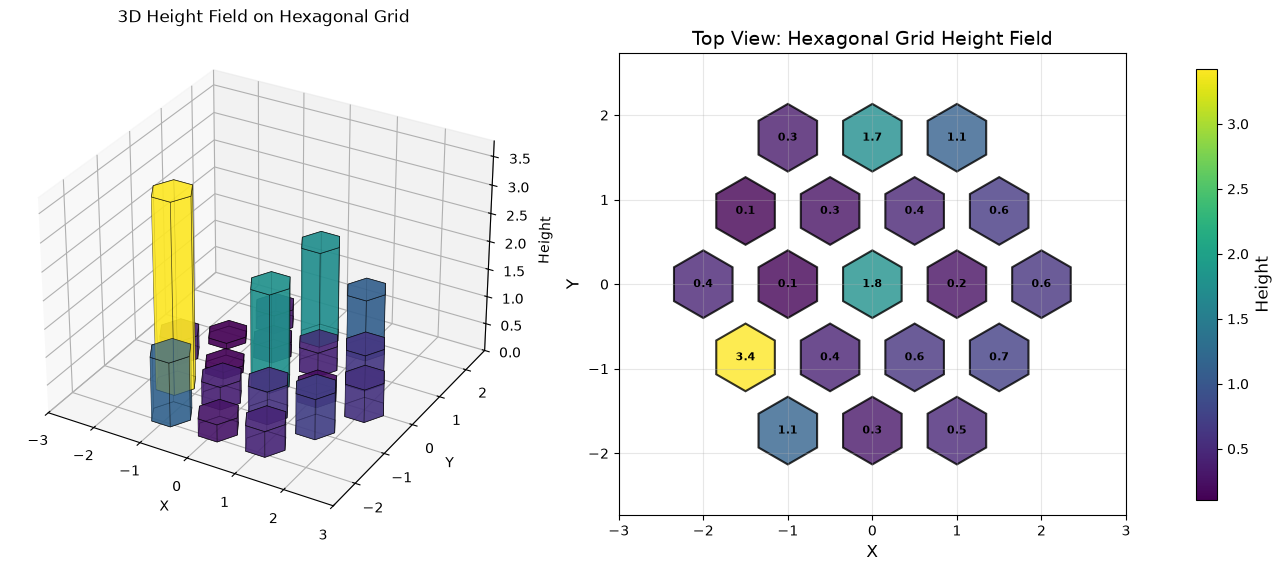

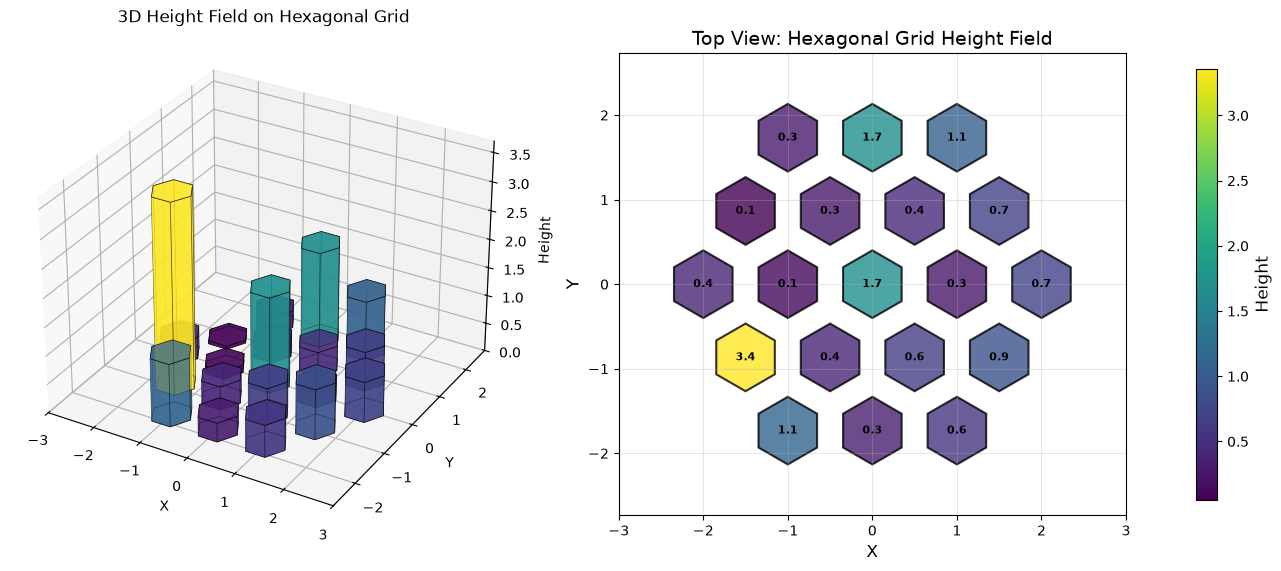

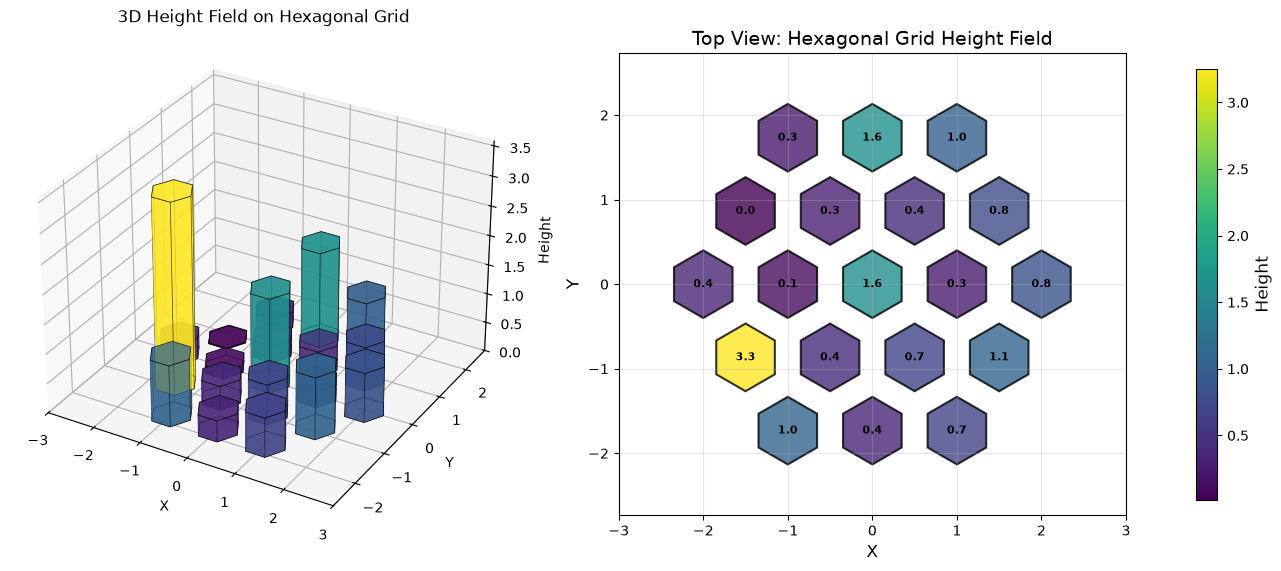

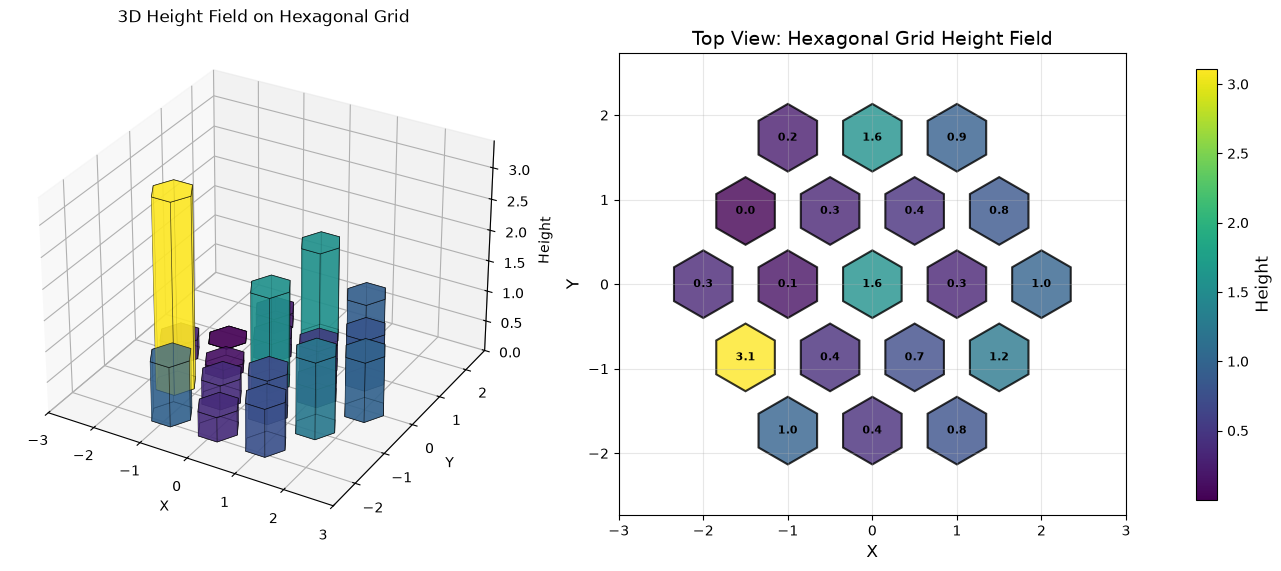

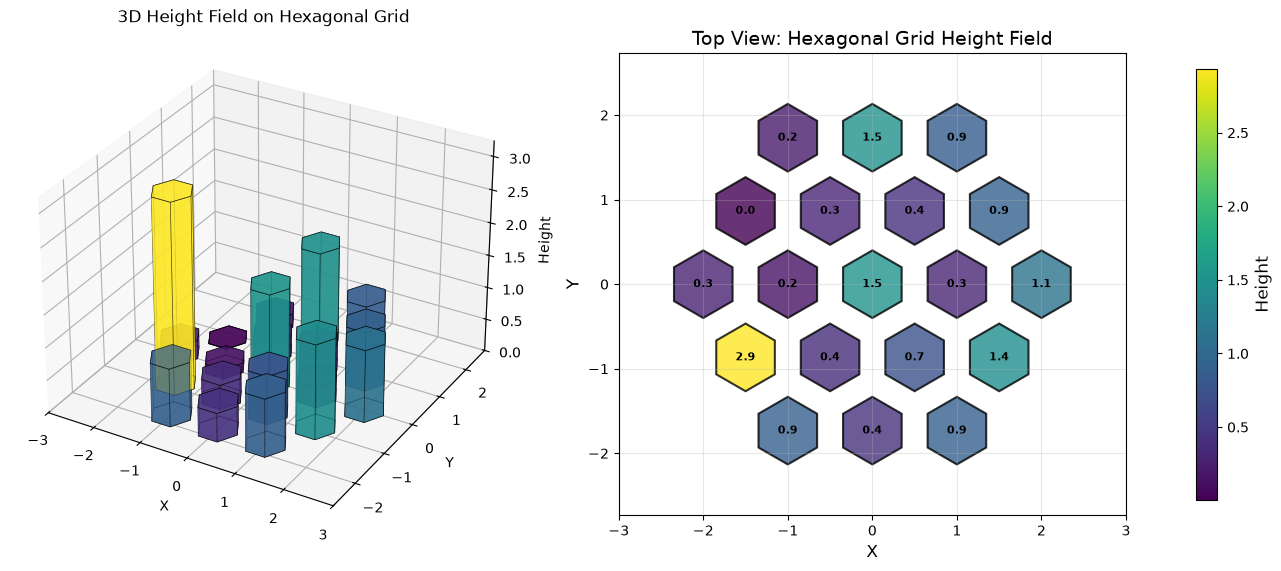

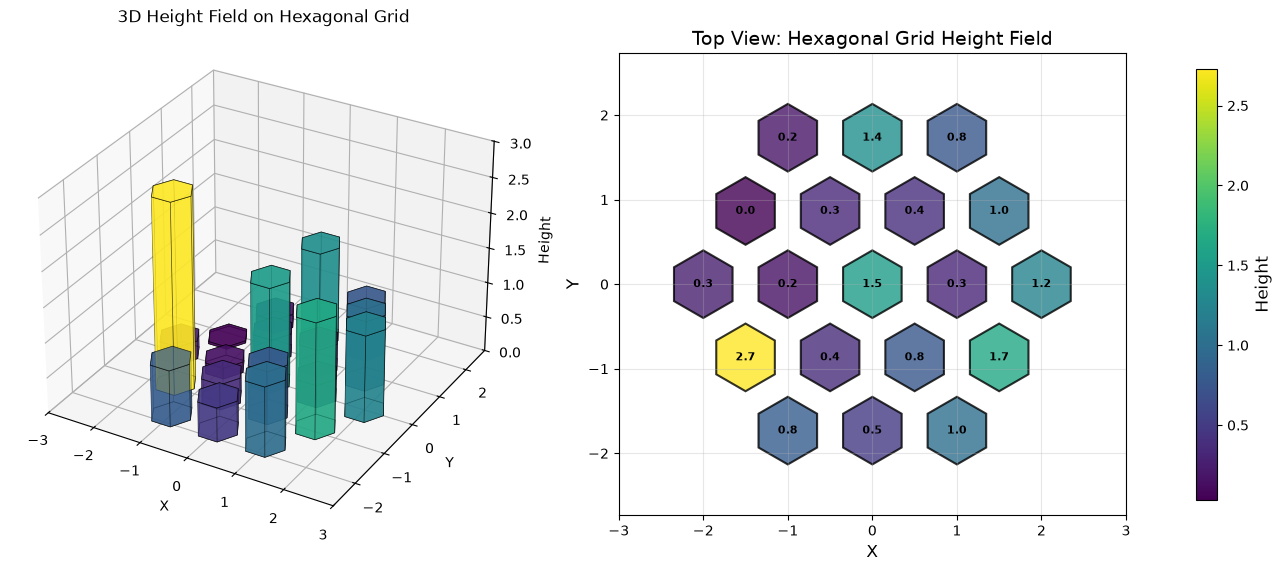

In [17]:

for i in range(len(uf_2d_batch1)):
    # Extract signals for field i
    signals = collect_subpixel_signals(uf_2d_batch1[i], x_min, y_min, dx, dy, core_centers)
    standardized = np.zeros(19)
    standardized[ideal_permutation] = signals*10
    display_hex_grid_plots(ideal_grid_positions, standardized)

In [18]:
# Build titles corresponding to our simulated aberration cube configurations
titles = [] #[f"Mode {c['mode_idx']} | {c['amplitude_nm']:.0f} nm" for c in aberration_configs]

from scipy.interpolate import RegularGridInterpolator, griddata
from scipy.ndimage import maximum_filter, map_coordinates
from scipy.optimize import linear_sum_assignment
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.patches import RegularPolygon

def calibrate_subpixel_centers(waveguide_modes_final, mesh_final):
    """Adaptive peak finder with dynamic threshold to detect all 19 cores."""
    plot_x_out = np.linspace(mesh_final.points[:, 0].min(), mesh_final.points[:, 0].max(), 400)
    plot_y_out = np.linspace(mesh_final.points[:, 1].min(), mesh_final.points[:, 1].max(), 400)
    X_plot_out, Y_plot_out = np.meshgrid(plot_x_out, plot_y_out)
    
    dx = plot_x_out[1] - plot_x_out[0]
    dy = plot_y_out[1] - plot_y_out[0]
    
    # Sum over modes to get total intensity profile
    if waveguide_modes_final.ndim == 2:
        total_modes_profile = np.sum(np.abs(waveguide_modes_final) ** 2, axis=0)
    else:
        total_modes_profile = np.abs(waveguide_modes_final) ** 2
    
    # Build 2D interpolation
    points_2d = np.column_stack((mesh_final.points[:, 0], mesh_final.points[:, 1]))
    total_modes_2d = griddata(points_2d, total_modes_profile, 
                              (X_plot_out, Y_plot_out), method='linear', fill_value=0.0)
    
    # Adaptive threshold to find exactly 19 peaks
    thresh = 0.1
    N_SIGNALS = 19
    peak_rows, peak_cols = [], []
    
    for attempt in range(15):
        is_peak = (total_modes_2d == maximum_filter(total_modes_2d, size=15)) & (total_modes_2d > thresh * np.max(total_modes_2d))
        peak_rows, peak_cols = np.where(is_peak)
        if len(peak_rows) == N_SIGNALS:
            print(f"[Peak Success] Resolved {N_SIGNALS} cores at threshold {thresh:.3f}.")
            break
        elif len(peak_rows) < N_SIGNALS:
            thresh *= 0.75   # Lower threshold to pick up weaker cores
        else:
            thresh *= 1.25   # Raise threshold to discard false splits
    else:
        print(f"⚠️ Warning: Found {len(peak_rows)} peaks instead of {N_SIGNALS}. Using closest configuration.")
    
    # Centroid refinement
    core_centers = []
    centroid_half_width = 4
    
    for r, c in zip(peak_rows, peak_cols):
        r_min, r_max = max(0, r - centroid_half_width), min(total_modes_2d.shape[0], r + centroid_half_width + 1)
        c_min, c_max = max(0, c - centroid_half_width), min(total_modes_2d.shape[1], c + centroid_half_width + 1)
        
        patch = total_modes_2d[r_min:r_max, c_min:c_max]
        r_indices, c_indices = np.meshgrid(np.arange(r_min, r_max), np.arange(c_min, c_max), indexing='ij')
        
        patch_sum = np.sum(patch)
        if patch_sum > 0:
            sub_pixel_row = np.sum(r_indices * patch) / patch_sum
            sub_pixel_col = np.sum(c_indices * patch) / patch_sum
            cx = plot_x_out[0] + sub_pixel_col * dx
            cy = plot_y_out[0] + sub_pixel_row * dy
        else:
            cx, cy = plot_x_out[c], plot_y_out[r]
        
        core_centers.append((cx, cy))
    
    return sorted(core_centers, key=lambda p: (np.round(p[1], 2), np.round(p[0], 2))), plot_x_out, plot_y_out, dx, dy

# =====================================================================
# 5. INTEGRITY GEOMETRIC ASSIGNMENT MATCHER (HUNGARIAN ALIGNMENT)
# =====================================================================
def map_evaluated_to_ideal_geometry(core_centers, ideal_centers_list):
    """Calculates optimal rigid alignment (Procrustes SVD) and assigns global indexes."""
    ideal_centers = np.array(ideal_centers_list)
    eval_centers = np.array(core_centers)
    
    ideal_centered = ideal_centers - np.mean(ideal_centers, axis=0)
    eval_centered = eval_centers - np.mean(eval_centers, axis=0)
    
    scale_ideal = np.sqrt(np.mean(np.sum(ideal_centered**2, axis=1)))
    scale_eval = np.sqrt(np.mean(np.sum(eval_centered**2, axis=1)))
    eval_scaled = eval_centered * (scale_ideal / scale_eval)
    
    H = np.dot(eval_scaled.T, ideal_centered)
    U, S, Vt = np.linalg.svd(H)
    R = np.dot(Vt.T, U.T)
    eval_aligned = np.dot(eval_scaled, R.T)
    
    diff = eval_aligned[:, np.newaxis, :] - ideal_centered[np.newaxis, :, :]
    cost_matrix = np.sqrt(np.sum(diff**2, axis=-1))
    eval_indices, ideal_permutation = linear_sum_assignment(cost_matrix)
    
    print(f"[Geometric Fit] Estimated physical core pitch: {scale_eval / scale_ideal:.3f} µm")
    print(f"[Geometric Fit] Residual matching RMS error: {np.mean(cost_matrix[eval_indices, ideal_permutation]):.4e}\n")
    
    return ideal_permutation

# =====================================================================
# 6. HIGH-LEVEL VISUALIZATION ENGINE
# =====================================================================
def display_hex_grid_plots(ideal_centers, standardized_signals):
    """Generates the concurrent side-by-side 3D column and 2D map views."""
    heights = standardized_signals * 1000
    centers = np.array(ideal_centers)
    hex_radius = 0.4
    
    vmin, vmax = heights.min(), heights.max()
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.viridis
    
    min_x, max_x = centers[:, 0].min() - 1, centers[:, 0].max() + 1
    min_y, max_y = centers[:, 1].min() - 1, centers[:, 1].max() + 1
    
    def create_hexagon_vertices(cx, cy, r):
        angles = np.linspace(0, 2 * np.pi, 7)[:-1]
        return np.column_stack((cx + r * np.cos(angles), cy + r * np.sin(angles)))

    fig = plt.figure(figsize=(18, 8))
    ax1 = fig.add_subplot(121, projection='3d')
    ax2 = fig.add_subplot(122)
    
    polys, colors_list, n_sides = [], [], 6
    for i, (x, y) in enumerate(centers):
        height = heights[i]
        color = cmap(norm(height))
        hex_vertices = create_hexagon_vertices(x, y, hex_radius)
        
        base_3d = np.column_stack((hex_vertices, np.zeros(n_sides)))
        top_3d = np.column_stack((hex_vertices, np.full(n_sides, height)))
        vertices_3d = np.vstack((base_3d, top_3d))
        
        polys.extend([vertices_3d[:n_sides], vertices_3d[n_sides:]])
        colors_list.extend([color, color])
        
        for j in range(n_sides):
            side_face = [vertices_3d[j], vertices_3d[(j+1)%n_sides], vertices_3d[(j+1)%n_sides + n_sides], vertices_3d[j + n_sides]]
            polys.append(side_face)
            colors_list.append(color)

    poly_collection = Poly3DCollection(polys, alpha=0.7, edgecolor='black', linewidth=0.5)
    poly_collection.set_facecolor(colors_list)
    ax1.add_collection3d(poly_collection)
    ax1.set_xlim(min_x, max_x); ax1.set_ylim(min_y, max_y); ax1.set_zlim(0, heights.max() * 1.1)
    ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Height')
    ax1.set_title('3D Height Field on Hexagonal Grid')
    
    for i, (x, y) in enumerate(centers):
        height = heights[i]
        hexagon = RegularPolygon((x, y), numVertices=6, radius=hex_radius, orientation=0,
                                 facecolor=cmap(norm(height)), edgecolor='black', linewidth=1.5, alpha=0.8)
        ax2.add_patch(hexagon)
        ax2.text(x, y, f'{height:.1f}', ha='center', va='center', fontsize=8, fontweight='bold')

    ax2.set_xlim(min_x, max_x); ax2.set_ylim(min_y, max_y); ax2.set_aspect('equal')
    ax2.set_xlabel('X', fontsize=12); ax2.set_ylabel('Y', fontsize=12)
    ax2.set_title('Top View: Hexagonal Grid Height Field', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=[ax1, ax2], pad=0.05, shrink=0.7).set_label('Height', fontsize=12)
    plt.show()

# Run the batch sub-pixel centroid track, integration capture, and geometric hex mapping
visualize_batch_hex_grid_signals(
    pipeline=pipeline,
    E_output_batch=E_output_batch[:5],
    ideal_grid_positions=ideal_grid_positions,               # From your earlier calibration cell
    calibrate_subpixel_centers=calibrate_subpixel_centers,   # Your tracking routine function
    collect_subpixel_signals=batch_collect_subpixel_signals,       # Your signal capture function
    map_evaluated_to_ideal_geometry=map_evaluated_to_ideal_geometry, # Matrix permuter
    display_hex_grid_plots=display_hex_grid_plots,           # Visual layout helper
    titles=titles,
    grid_resolution=400
)

NameError: name 'E_output_batch' is not defined

In [ ]:
visualize_batch_hex_grid_signals(
    pipeline=pipeline,
    E_output_batch=E_output_batch[:2],
    ideal_grid_positions=ideal_grid_positions,
    calibrate_subpixel_centers=None,  # not needed
    collect_subpixel_signals=collect_subpixel_signals,
    map_evaluated_to_ideal_geometry=map_evaluated_to_ideal_geometry,
    display_hex_grid_plots=display_hex_grid_plots,
    titles=titles,
    grid_resolution=400
)

In [ ]:
# =====================================================================
# CELL 12: BATCH STATISTICS AND ANALYSIS
# =====================================================================

print("\nComputing batch statistics...\n")

batch_statistics(uf_batch, titles)

# Additional analysis: Mode coupling
print("\n" + "="*60)
print("MODE COUPLING ANALYSIS")
print("="*60)

for i in [0, 10, -1]:
    config = aberration_configs[i]
    mode_powers = np.abs(uf_batch[i])**2
    top_3_indices = np.argsort(mode_powers)[-3:][::-1]
    
    print(f"\n{titles[i]}:")
    print(f"  Top 3 output modes: {top_3_indices}")
    print(f"  Their powers: {mode_powers[top_3_indices]}")
    print(f"  Concentrated power: {np.sum(mode_powers[top_3_indices]):.4f}")

In [ ]:
# =====================================================================
# CELL 13: EXTRACT AND ANALYZE SPECIFIC METRICS
# =====================================================================

# Compute power in different mode groups
print("\n" + "="*60)
print("POWER DISTRIBUTION ANALYSIS")
print("="*60)

def analyze_power_distribution(uf_batch):
    """Analyze how power distributes among modes."""
    n_fields = uf_batch.shape[0]
    
    fundamental_power = np.abs(uf_batch[:, 0])**2
    top_3_power = np.sum(np.abs(uf_batch[:, :3])**2, axis=1)
    top_5_power = np.sum(np.abs(uf_batch[:, :5])**2, axis=1)
    total_power = np.sum(np.abs(uf_batch)**2, axis=1)
    
    return {
        'fundamental': fundamental_power,
        'top_3': top_3_power,
        'top_5': top_5_power,
        'total': total_power
    }

power_dist = analyze_power_distribution(uf_batch)

print(f"\nFundamental Mode Power:")
print(f"  Mean: {np.mean(power_dist['fundamental']):.4f}")
print(f"  Std: {np.std(power_dist['fundamental']):.4f}")
print(f"  Min: {np.min(power_dist['fundamental']):.4f}")
print(f"  Max: {np.max(power_dist['fundamental']):.4f}")

print(f"\nTop 3 Modes Power:")
print(f"  Mean: {np.mean(power_dist['top_3']):.4f}")
print(f"  Std: {np.std(power_dist['top_3']):.4f}")

In [ ]:
# =====================================================================
# CELL 14: SAVE RESULTS FOR POST-PROCESSING
# =====================================================================

import pickle
from pathlib import Path

# Create results directory
results_dir = Path('batch_results')
results_dir.mkdir(exist_ok=True)

# Save data
results = {
    'u0_batch': u0_batch,
    'uf_batch': uf_batch,
    'E_output_batch': E_output_batch[:10],
    'uf_2d_batch': uf_2d_batch,
    'zs': zs,
    'us_batch': us_batch,
    'configs': aberration_configs,
    'X_plot': X_plot,
    'Y_plot': Y_plot
}

# Save as pickle
with open(results_dir / 'batch_results.pkl', 'wb') as f:
    pickle.dump(results, f)

# Also save numpy arrays separately for easier access
np.save(results_dir / 'u0_batch.npy', u0_batch)
np.save(results_dir / 'uf_batch.npy', uf_batch)
np.save(results_dir / 'uf_2d_batch.npy', uf_2d_batch)

print(f"Results saved to {results_dir}/")
print(f"  - batch_results.pkl (complete results)")
print(f"  - u0_batch.npy (input modal coefficients)")
print(f"  - uf_batch.npy (output modal coefficients)")
print(f"  - uf_2d_batch.npy (output intensity maps)")

In [ ]:
# =====================================================================
# CELL 15: MODE EVOLUTION ALONG PROPAGATION
# =====================================================================

# Analyze how modes evolve during propagation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Select 4 representative fields
selected_indices = [0, len(aberration_configs)//3, 2*len(aberration_configs)//3, -1]

for ax, idx in zip(axes.flat, selected_indices):
    # us_batch shape: (n_fields, n_z, n_modes)
    # We want the evolution of the top 3 modes for field idx
    
    evolution = us_batch[idx]  # shape: (n_z, n_modes)
    
    # Find top 3 output modes
    output_powers = np.abs(uf_batch[idx])**2
    top_modes = np.argsort(output_powers)[-3:][::-1]
    
    # Plot evolution
    for mode_idx in top_modes:
        mode_evolution = np.abs(evolution[:, mode_idx])**2
        ax.plot(zs, mode_evolution, label=f'Mode {mode_idx}')
    
    ax.set_xlabel('z (μm)')
    ax.set_ylabel('Power')
    ax.set_title(titles[idx])
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Mode Power Evolution During Propagation')
plt.tight_layout()
plt.show()

In [ ]:
# =====================================================================
# CELL 16: EXPORT TO HDF5 FOR EXTERNAL ANALYSIS
# =====================================================================

try:
    import h5py
    
    filename = results_dir / 'batch_results.h5'
    
    with h5py.File(filename, 'w') as f:
        # Input/output modal coefficients
        f.create_dataset('u0_batch', data=u0_batch)
        f.create_dataset('uf_batch', data=uf_batch)
        
        # Evolution
        f.create_dataset('zs', data=zs)
        f.create_dataset('us_batch', data=us_batch)
        
        # Grid data
        f.create_dataset('X_plot', data=X_plot)
        f.create_dataset('Y_plot', data=Y_plot)
        f.create_dataset('uf_2d_batch', data=uf_2d_batch)
        
        # Metadata
        f.attrs['n_fields'] = len(aberration_configs)
        f.attrs['n_modes'] = uf_batch.shape[1]
        f.attrs['n_z_points'] = len(zs)
        f.attrs['wavelength_um'] = p['wl']
        f.attrs['lantern_length_um'] = p['z_ex']
    
    print(f"HDF5 file saved: {filename}")
except ImportError:
    print("h5py not installed. Skipping HDF5 export.")